In [ ]:
# Instala a biblioteca do YOLO11
# Instala a biblioteca do YOLO11
%pip install ultralytics 


# Verifica se a GPU foi reconhecida
print(f"GPU disponível: {torch.cuda.is_available()}")

import os
import yaml
from ultralytics import YOLO

# Verifica se a GPU foi reconhecida
import torch
import os
import yaml
from ultralytics import YOLO
print(f"GPU disponível: {torch.cuda.is_available()}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
GPU disponível: False


In [2]:
# Caminho onde o Kaggle montou seu dataset (ajuste o nome da pasta)
dataset_path = '/kaggle/input/dataset-tcc'

data_config = {
    'path': dataset_path,
    'train': 'training/images',
    'val': 'validation/images',
    'test': 'testing/images',
    'names': {
        0: 'car_mercosur',
        1: 'car_brazilian',
        2: 'motorcycle_mercosur',
        3: 'motorcycle_brazilian'
    }
}

# Salva o arquivo na pasta de trabalho do Kaggle
with open('/kaggle/working/data.yaml', 'w') as f:
    yaml.dump(data_config, f)

In [3]:
import os

# Esse comando vai listar tudo o que está na pasta de entrada
for root, dirs, files in os.walk('/kaggle/input'):
    level = root.replace('/kaggle/input', '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f"{indent}{os.path.basename(root)}/")

input/
    datasets/
        joaomarcosgil/
            dataset-tcc/
                dataset/
                    validation/
                        labels/
                        images/
                    training/
                        labels/
                        images/
                    testing/
                        labels/
                        images/
            pesos-yolo-tcc/


In [4]:
import yaml

# O caminho completo exato baseado no seu retorno do comando 'os.walk'
dataset_path = '/kaggle/input/datasets/joaomarcosgil/dataset-tcc/dataset'

data_config = {
    'path': dataset_path,
    'train': 'training/images', 
    'val': 'validation/images', 
    'test': 'testing/images',
    'names': {
        0: 'car_mercosur',
        1: 'car_brazilian',
        2: 'motorcycle_mercosur',
        3: 'motorcycle_brazilian'
    }
}

with open('/kaggle/working/data.yaml', 'w') as f:
    yaml.dump(data_config, f)
    
print("Arquivo data.yaml atualizado com o caminho correto!")

Arquivo data.yaml atualizado com o caminho correto!


In [5]:
from ultralytics import YOLO

# Carrega o modelo pré-treinado para Fine-Tuning [cite: 275]
# model = YOLO('yolo11n.pt') 

# 1. Modelo treinado (Dataset), não o 'yolo11n.pt'
model = YOLO('/kaggle/input/datasets/joaomarcosgil/pesos-yolo-tcc/best.pt')

# Inicia o treinamento focado no padrão brasileiro e Mercosul [cite: 276]
# 2. COMENTE este bloco inteiro para não gastar tempo treinando de novo
# results = model.train(
#    data='/kaggle/input/datasets/joaomarcosgil/dataset-tcc/dataset/data.yaml',
#    epochs=50,
#    imgsz=640,
#    name='experimento_placas_v1',
#    project='TCC_FAESA',
#    device=0
# )

print("✅ Modelo carregado para inferência. O treino foi pulado.")

✅ Modelo carregado para inferência. O treino foi pulado.


Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


✅ Processo concluído em poucos minutos!


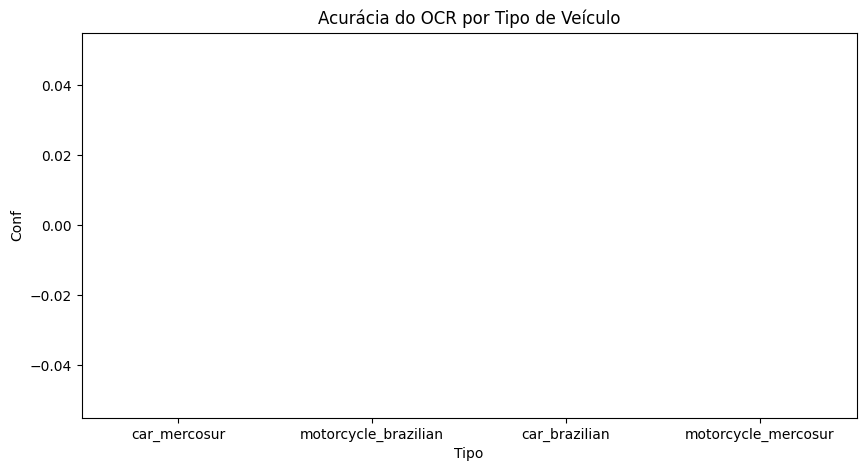

In [6]:
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import easyocr
from ultralytics import YOLO

# 1. Caminho que você confirmou agora pouco
model_path = '/kaggle/input/datasets/joaomarcosgil/pesos-yolo-tcc/best.pt'
img_dir = '/kaggle/input/datasets/joaomarcosgil/dataset-tcc/dataset/validation/images'

# 2. Carrega o modelo (sem treinar nada!)
model = YOLO(model_path)
reader = easyocr.Reader(['en'], gpu=True) 

# 3. Cria a pasta para você baixar os resultados depois
output_dir = '/kaggle/working/validacao_ocr_final'
os.makedirs(output_dir, exist_ok=True)

# 4. Executa a leitura
results_list = []
images = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png'))][:25]

for img_name in images:
    path = os.path.join(img_dir, img_name)
    img = cv2.imread(path)
    yolo_results = model(path, verbose=False)
    
    for r in yolo_results:
        for box in r.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            label = model.names[int(box.cls[0])]
            
            crop = img[y1:y2, x1:x2]
            ocr_result = reader.readtext(crop)
            
            texto = "N/A"
            confianca = 0.0
            if ocr_result:
                texto = ocr_result[0][1].upper().replace(" ", "")
                confianca = ocr_result[0][2]
            
            results_list.append({"Ficheiro": img_name, "Tipo": label, "Texto": texto, "Conf": confianca})
            
            # Desenha na imagem para o seu artigo
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(img, f"{texto}", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    cv2.imwrite(os.path.join(output_dir, f"resultado_{img_name}"), img)

# 5. Gera o gráfico para o relatório técnico
df = pd.DataFrame(results_list)
plt.figure(figsize=(10, 5))
sns.barplot(x='Tipo', y='Conf', data=df, hue='Tipo', palette='viridis', legend=False)
plt.title('Acurácia do OCR por Tipo de Veículo')
plt.savefig('/kaggle/working/grafico_ocr.png')
df.to_csv('/kaggle/working/resultados_ocr.csv', index=False)

print("✅ Processo concluído em poucos minutos!")